In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [4]:
# Fix TotalCharges (same issue as SQL)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove null rows
df.dropna(inplace=True)

# Convert churn to numeric
df['Churn_Flag'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

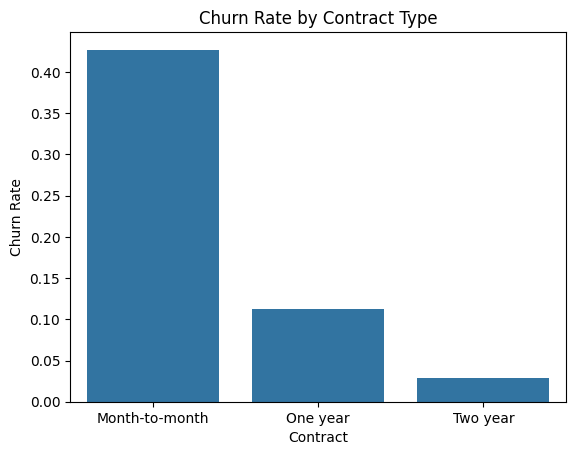

In [5]:
churn_by_contract = df.groupby('Contract')['Churn_Flag'].mean().reset_index()

sns.barplot(x='Contract', y='Churn_Flag', data=churn_by_contract)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

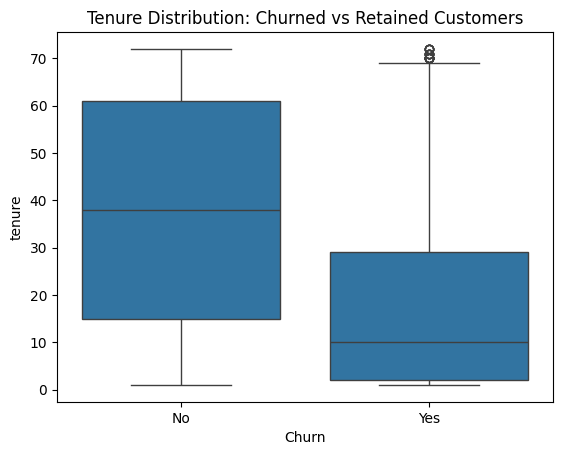

In [6]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution: Churned vs Retained Customers')
plt.show()

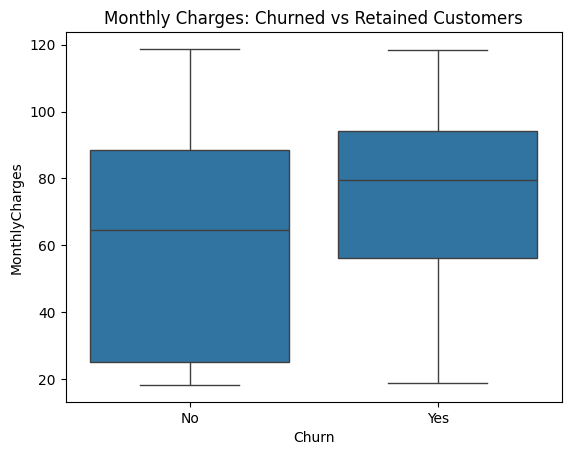

In [7]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges: Churned vs Retained Customers')
plt.show()

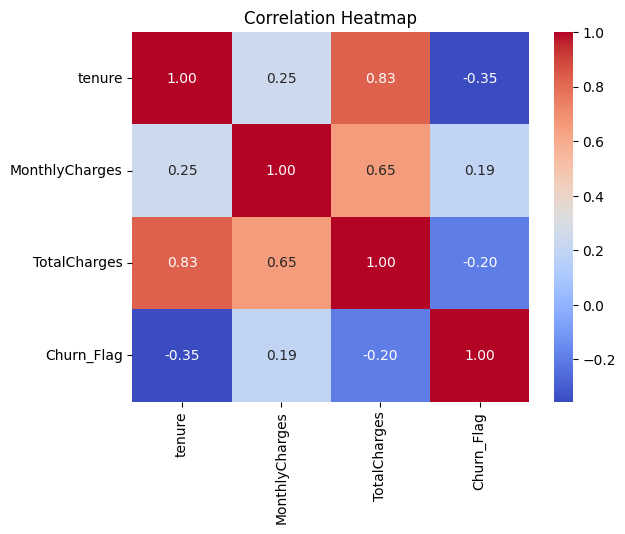

In [8]:
# Select numeric columns
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Flag']]

# Create heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()